# Neural network classification with pytorch

In [16]:
from sklearn.datasets import make_circles

# Make 1000 samples with noise
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state= 42)

In [17]:
len(X), len(y)
# Output the number of samples and labels

(1000, 1000)

In [18]:
print(f"First five X samples:\n{X[:5]}")
print(f"First five y labels:\n{y[:5]}")
# Output the first five samples and labels

First five X samples:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five y labels:
[1 1 1 1 0]


In [24]:
import pandas as pd
circles = pd.DataFrame(X, columns=['x1', 'x2'])
circles.head()

,x1,x2
0,0.754246,0.231481
1,-0.756159,0.153259
2,-0.815392,0.173282
3,-0.393731,0.692883
4,0.442208,-0.896723


In [29]:
circles['label'] = y
circles.head(10)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


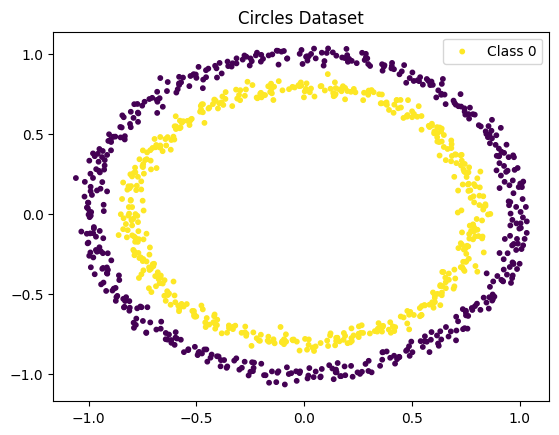

In [32]:
import matplotlib.pyplot as plt
plt.scatter(circles['x1'], circles['x2'], c=circles['label'], cmap='viridis', s=10)
plt.title('Circles Dataset')
plt.legend(['Class 0', 'Class 1'])

In [33]:
# Check input and output shapes
print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")

Input shape: (1000, 2)
Output shape: (1000,)


In [38]:
# Turn numpy arrays into PyTorch tensors
X = torch.tensor(X_train, dtype=torch.float32).to(device)
y = torch.tensor(y_train, dtype=torch.float32).to(device)
X[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]], device='cuda:0')

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, {y_train.shape}")

Training set shape: torch.Size([640, 2]), torch.Size([640])


In [40]:
import torch
import torch.nn as nn

# Make device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [41]:
X_train

tensor([[-0.7052,  0.7271],
        [ 0.4221, -0.9372],
        [-0.9503,  0.4067],
        ...,
        [ 0.8320,  0.0444],
        [ 1.0294,  0.0438],
        [ 0.9073,  0.1618]], device='cuda:0')

In [42]:
X_train.shape

torch.Size([640, 2])

In [47]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
        
    def forward(self, x):
        return self.layer_2(self.layer_1(x))

# Instantiate the model
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)